In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import phd_parser as pp

In [3]:
from phd_parser.raman.btc655n import read_export

In [4]:
filepath_tio2 = Path(r"..\tests\raman\test_tio2.txt")
filepath_nolaser = Path(r"..\tests\raman\test_nolaser.txt")


tio2 = read_export(filepath_tio2)
nolaser = read_export(filepath_nolaser)

In [5]:
tio2["data"].columns

Index(['Pixel', 'Wavelength', 'Wavenumber', 'Raman Shift', 'Dark', 'Reference',
       'Raw data #1', 'Dark Subtracted #1', '%TR #1', 'Absorbance #1',
       'Irradiance (lumen) #1'],
      dtype='str')

In [6]:
df = tio2["data"]["Dark Subtracted #1"] - nolaser["data"]["Dark Subtracted #1"]

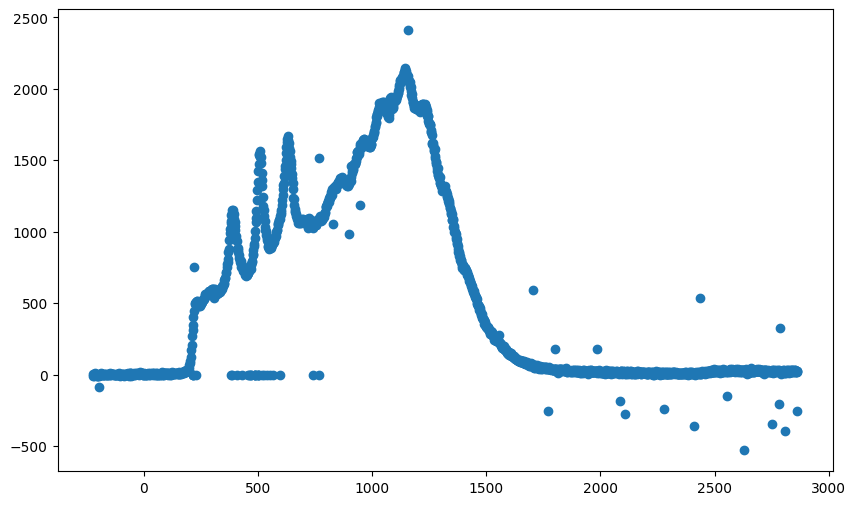

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tio2["data"]['Raman Shift'], tio2["data"]['Dark Subtracted #1'])
plt.show()

In [10]:
import ramanspy as rp

In [61]:
rp_spectrum = rp.Spectrum(
    spectral_data = tio2["data"]['Dark Subtracted #1'],
    spectral_axis = tio2["data"]['Raman Shift']
)

<Axes: title={'center': 'Raman spectra'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

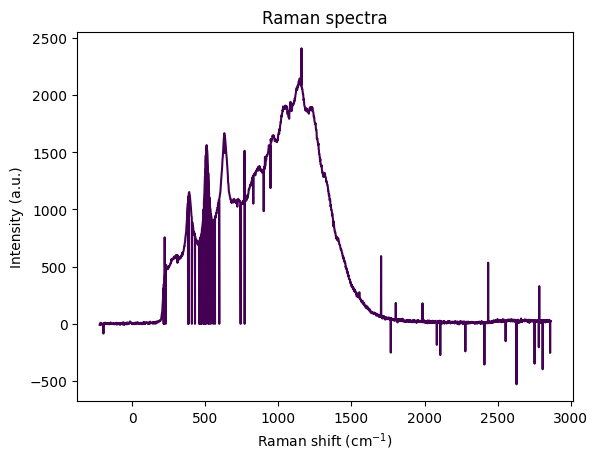

In [62]:
rp_spectrum.plot()

In [ ]:
pipeline = rp.preprocessing.Pipeline(
    [
        rp.preprocessing.despike.WhitakerHayes(kernel_size=1, threshold=3),

    ]
)
data = pipeline.apply(rp_spectrum)

<Axes: title={'center': 'Raman spectra'}, xlabel='Raman shift (cm$^{{{-1}}}$)', ylabel='Intensity (a.u.)'>

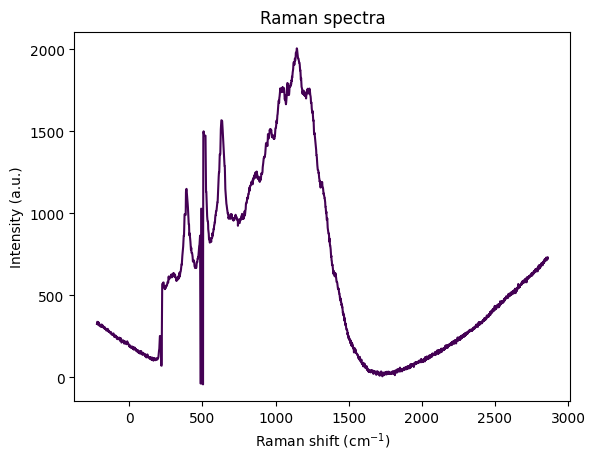

In [64]:
data.plot()